# Ejercicio 6. Dieta de costo mínimo mediante un algoritmo genético multi-objetivo

Curso de Inteligencia Artificial. Capítulo 3, Algoritmos Genéticos (José J. Martínez P.)

Ejercicio 3.10, numeral 6.

---

## 1. Definición del problema

El enunciado pide tomar el algoritmo de la dieta e incluir los costos, de manera que se encuentre
una dieta que trate de satisfacer los requerimientos nutricionales con un costo mínimo, y
señala que se trata de un ejemplo de algoritmo genético multi-objetivo con dos funciones
objetivo.

El problema de la dieta consiste en determinar cuántas porciones de cada alimento se deben
consumir diariamente para cubrir los requerimientos nutricionales de una persona. Al incorporar
el costo aparecen dos objetivos que se encuentran en conflicto:

$$f_1(X) = \text{deficiencia nutricional} \longrightarrow \min$$

$$f_2(X) = \text{costo diario de la canasta} \longrightarrow \min$$

El conflicto es real y no artificial: los alimentos con mayor densidad nutricional, como el
pollo, la leche o el huevo, son también los más costosos por porción. En consecuencia no existe
una única solución óptima sino un conjunto de soluciones no dominadas, es decir, soluciones en
las cuales no es posible mejorar la nutrición sin encarecer la canasta, ni abaratarla sin
empeorar la nutrición. Ese conjunto es el frente de Pareto descrito en la sección 3.9 del
capítulo.

El problema pertenece además a la familia del problema del furgón o de la mochila presentado en
la sección 3.7, en el cual los elementos poseen un peso, aquí el costo, y un valor de utilidad,
aquí el aporte nutricional, sujetos a restricciones. Se trata de un problema NP-Completo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

rng = np.random.default_rng(6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

ALIMENTOS = ["Arroz (taza)", "Fríjol (taza)", "Huevo (und)", "Pollo (100 g)",
             "Leche (vaso)", "Banano (und)", "Papa (und)", "Lenteja (taza)",
             "Zanahoria (und)", "Pan integral (tajada)"]

NUTRIENTES = ["Calorías (kcal)", "Proteína (g)", "Calcio (mg)",
              "Hierro (mg)", "Vitamina C (mg)", "Fibra (g)"]

# Aporte nutricional por porcion
NUTR = np.array([
    #  kcal  prot  calcio hierro vitC  fibra
    [  205,  4.3,   16,   1.9,   0.0,  0.6],   # arroz
    [  245, 15.0,   80,   3.6,   1.5, 15.0],   # frijol
    [   72,  6.3,   28,   0.9,   0.0,  0.0],   # huevo
    [  165, 31.0,   15,   1.0,   0.0,  0.0],   # pollo
    [  150,  8.0,  300,   0.1,   2.4,  0.0],   # leche
    [  105,  1.3,    6,   0.3,  10.3,  3.1],   # banano
    [  160,  4.3,   26,   1.9,  42.0,  3.8],   # papa
    [  230, 18.0,   38,   6.6,   3.0, 15.6],   # lenteja
    [   25,  0.6,   20,   0.2,   3.6,  1.7],   # zanahoria
    [   69,  3.6,   30,   0.7,   0.0,  1.9],   # pan integral
])

# Costo por porcion en pesos colombianos
COSTO = np.array([700., 1200., 750., 3200., 1400., 900., 600., 1100., 400., 500.])

# Requerimientos diarios minimos de un adulto
REQ = np.array([2000., 50., 1000., 14., 60., 25.])
MAX_PORCIONES = 4        # tope de porciones diarias de un mismo alimento
NA_ = len(ALIMENTOS)

print(pd.DataFrame(np.column_stack([NUTR, COSTO]), index=ALIMENTOS,
                   columns=NUTRIENTES + ["Costo ($)"]).to_string())
print("\nRequerimiento diario minimo:")
print(pd.Series(REQ, index=NUTRIENTES).to_string())
print(f"\nTope de {MAX_PORCIONES} porciones por alimento: "
      f"{(MAX_PORCIONES+1)**NA_:,} dietas posibles")

                       Calorías (kcal)  Proteína (g)  Calcio (mg)  Hierro (mg)  Vitamina C (mg)  Fibra (g)  Costo ($)
Arroz (taza)                     205.0           4.3         16.0          1.9              0.0        0.6      700.0
Fríjol (taza)                    245.0          15.0         80.0          3.6              1.5       15.0     1200.0
Huevo (und)                       72.0           6.3         28.0          0.9              0.0        0.0      750.0
Pollo (100 g)                    165.0          31.0         15.0          1.0              0.0        0.0     3200.0
Leche (vaso)                     150.0           8.0        300.0          0.1              2.4        0.0     1400.0
Banano (und)                     105.0           1.3          6.0          0.3             10.3        3.1      900.0
Papa (und)                       160.0           4.3         26.0          1.9             42.0        3.8      600.0
Lenteja (taza)                   230.0          18.0    

## 2. Representación de los individuos

El cromosoma es una lista de diez genes enteros, cada uno correspondiente al número de porciones
diarias de un alimento:

$$X = [x_1, x_2, \dots, x_{10}], \qquad x_i \in \{0,1,2,3,4\}$$

Con diez alimentos y cinco niveles posibles, el espacio de búsqueda contiene
$5^{10} = 9\,765\,625$ dietas. Este tamaño se escogió de forma deliberada: es suficientemente
grande para que la enumeración no sea trivial y suficientemente pequeño para permitir el cálculo
del frente de Pareto exacto por fuerza bruta, lo que hace posible verificar con certeza la
calidad de la aproximación obtenida por el algoritmo genético.

In [2]:
def genera(K):
    return rng.integers(0, MAX_PORCIONES + 1, size=(K, NA_))

def nutrientes(pob):
    return pob @ NUTR                   # matriz (K, 6)

def costo(pob):
    return pob @ COSTO                  # vector (K,)

ej = genera(3)
for c in ej:
    n = c @ NUTR
    print(f"Dieta {list(c)}  ->  costo $ {c @ COSTO:,.0f}   "
          f"{n[0]:.0f} kcal, {n[1]:.1f} g de proteina, {n[2]:.0f} mg de calcio")

Dieta [np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(4), np.int64(1), np.int64(3), np.int64(1), np.int64(2), np.int64(4)]  ->  costo $ 20,700   2950 kcal, 162.0 g de proteina, 1745 mg de calcio
Dieta [np.int64(0), np.int64(3), np.int64(2), np.int64(3), np.int64(3), np.int64(1), np.int64(3), np.int64(3), np.int64(2), np.int64(0)]  ->  costo $ 25,700   3149 kcal, 244.0 g de proteina, 1479 mg de calcio
Dieta [np.int64(3), np.int64(0), np.int64(4), np.int64(4), np.int64(4), np.int64(0), np.int64(4), np.int64(4), np.int64(2), np.int64(4)]  ->  costo $ 33,100   4049 kcal, 298.9 g de proteina, 1836 mg de calcio

## 3. Las dos funciones objetivo

### Objetivo 1: deficiencia nutricional

Se mide como la suma de los faltantes relativos respecto a cada requerimiento. Se toman
faltantes relativos y no absolutos para que un déficit de calcio, expresado en miligramos sobre
un requerimiento de 1000, y un déficit de hierro, expresado en miligramos sobre un requerimiento
de 14, contribuyan con el mismo peso:

$$f_1(X) = \sum_{n=1}^{6}\max\!\left(0,\ \frac{R_n - \sum_i x_i N_{in}}{R_n}\right)$$

Un valor $f_1 = 0$ indica que la dieta es nutricionalmente completa. El valor máximo es 6, que
corresponde a no consumir nada.

### Objetivo 2: costo

$$f_2(X) = \sum_{i} x_i\,c_i$$

Ninguno de los dos objetivos se convierte en restricción. Ambos se optimizan de forma
simultánea, que es precisamente lo que caracteriza a un algoritmo genético multi-objetivo.

In [3]:
def objetivos(pob):
    "Devuelve (f1 = deficiencia relativa, f2 = costo diario)."
    n  = pob @ NUTR
    f1 = np.maximum(0, (REQ - n) / REQ).sum(axis=1)
    f2 = pob @ COSTO
    return f1, f2

f1, f2 = objetivos(genera(5))
for a, b in zip(f1, f2):
    print(f"deficiencia = {a:.4f}   costo = $ {b:,.0f}")

deficiencia = 0.0820   costo = $ 15,800
deficiencia = 0.0000   costo = $ 17,950
deficiencia = 0.3389   costo = $ 12,000
deficiencia = 0.0000   costo = $ 19,150
deficiencia = 0.0700   costo = $ 28,600

## 4. Punto de partida: el algoritmo de la dieta sin costos

Antes de construir la versión multi-objetivo se ejecuta el algoritmo de la dieta en su forma
original, es decir, un algoritmo genético mono-objetivo que busca únicamente cubrir los
requerimientos nutricionales sin considerar el precio. Su resultado sirve de referencia para
cuantificar el beneficio de incorporar el segundo objetivo.

Los operadores son los que corresponden a genes enteros: selección por torneo de tamaño 3, cruce
uniforme y mutación mixta. Esta última reemplaza el gen por un valor aleatorio en la mitad de los
casos, lo que favorece la exploración, y lo desplaza en una unidad en la otra mitad, lo que
favorece el ajuste fino.

In [4]:
def seleccion_torneo(pob, apt, t=3):
    idx = rng.integers(0, len(pob), size=(len(pob), t))
    gan = idx[np.arange(len(pob)), np.argmax(apt[idx], axis=1)]
    return pob[gan].copy()

def cruce_uniforme(padres):
    hijos = padres.copy()
    for i in range(0, len(padres) - 1, 2):
        m = rng.random(NA_) < 0.5
        hijos[i][m], hijos[i+1][m] = padres[i+1][m], padres[i][m]
    return hijos

def mutacion(hijos, p_mut=0.12):
    "Mutacion mixta: mitad reemplazo aleatorio y mitad desplazamiento de una porcion."
    m = rng.random(hijos.shape) < p_mut
    n = int(m.sum())
    if n:
        nuevo = rng.integers(0, MAX_PORCIONES + 1, size=n)
        paso  = hijos[m] + rng.choice([-1, 1], size=n)
        usa_paso = rng.random(n) < 0.5
        hijos[m] = np.clip(np.where(usa_paso, paso, nuevo), 0, MAX_PORCIONES)
    return hijos

def ag_mono(M=150, K=100, semilla=6):
    global rng
    rng = np.random.default_rng(semilla)
    pob = genera(K)
    hist = []
    for g in range(M):
        d, c = objetivos(pob)
        apt = 1.0 / (1.0 + d)                    # solo interviene la deficiencia
        hist.append(float(d.min()))
        elites = pob[np.argsort(-apt)[:2]].copy()
        pob = mutacion(cruce_uniforme(seleccion_torneo(pob, apt)))
        pob[:2] = elites
    d, c = objetivos(pob)
    completas = d < 1e-12
    i = int(np.argmin(np.where(completas, c, np.inf))) if completas.any() else int(np.argmin(d))
    return pob[i], d[i], c[i], np.array(hist)

dieta_mono, d_mono, c_mono, hist_mono = ag_mono()
print("Algoritmo genetico mono-objetivo, solo satisfacer la dieta:")
print("   Dieta :", {a.split(" ")[0]: int(v) for a, v in zip(ALIMENTOS, dieta_mono) if v})
print(f"   Deficiencia = {d_mono:.6f}    Costo = $ {c_mono:,.0f} por dia")

Algoritmo genetico mono-objetivo, solo satisfacer la dieta:
   Dieta : {'Arroz': 1, 'Huevo': 2, 'Leche': 4, 'Papa': 4, 'Lenteja': 1, 'Zanahoria': 4, 'Pan': 3}
   Deficiencia = 0.000000    Costo = $ 14,400 por dia

## 5. El algoritmo multi-objetivo: NSGA-II

Cuando existen dos objetivos en conflicto no es posible definir una aptitud escalar sin imponer
de antemano una ponderación entre ellos, ponderación que sería arbitraria y que ocultaría las
demás soluciones de compromiso. Se implementa por tanto NSGA-II, que es el algoritmo genético
multi-objetivo de uso más extendido, y que consta de tres piezas:

1. Ordenamiento por no dominancia. Se dice que $X$ domina a $Y$ si $X$ no es peor que $Y$ en
   ningún objetivo y es mejor en al menos uno. El primer frente está formado por los cromosomas
   que no son dominados por ninguno; el segundo, por los que no son dominados una vez retirado
   el primero, y así sucesivamente.
2. Distancia de apiñamiento. Dentro de un mismo frente se prefieren las soluciones situadas en
   zonas poco pobladas, con el fin de que el frente resultante quede bien distribuido y no se
   concentre en uno de sus extremos.
3. Supervivencia elitista de tipo $(\mu + \lambda)$. Padres e hijos compiten conjuntamente,
   primero por número de frente y, dentro de un mismo frente, por distancia de apiñamiento.

Los operadores de cruce y mutación son los mismos de la sección anterior. Lo que cambia es el
criterio mediante el cual se decide qué individuos sobreviven.

In [5]:
def frentes_no_dominados(f1, f2):
    "Ordenamiento por no dominancia. Devuelve el numero de frente de cada individuo."
    n = len(f1)
    domina = (f1[:, None] <= f1[None, :]) & (f2[:, None] <= f2[None, :]) & \
             ((f1[:, None] < f1[None, :]) | (f2[:, None] < f2[None, :]))
    n_dom = domina.sum(axis=0)          # cuantos individuos dominan a cada uno
    rango = np.full(n, -1)
    actual, r = np.where(n_dom == 0)[0], 0
    while len(actual):
        rango[actual] = r
        n_dom = n_dom - domina[actual].sum(axis=0)
        n_dom[actual] = 10**9
        actual = np.where(n_dom == 0)[0]
        r += 1
    rango[rango < 0] = r
    return rango

def apinamiento(f1, f2, rango):
    "Distancia de apiñamiento dentro de cada frente."
    d = np.zeros(len(f1))
    for r in np.unique(rango):
        idx = np.where(rango == r)[0]
        for f in (f1, f2):
            o = idx[np.argsort(f[idx])]
            d[o[0]] = d[o[-1]] = np.inf          # los extremos siempre se conservan
            amplitud = f[o[-1]] - f[o[0]]
            if amplitud > 0 and len(o) > 2:
                d[o[1:-1]] += (f[o[2:]] - f[o[:-2]]) / amplitud
    return d

def nsga2(M=600, K=150, p_mut=0.30, semilla=6):
    global rng
    rng = np.random.default_rng(semilla)
    pob = genera(K)
    historia = []
    for g in range(M):
        f1, f2 = objetivos(pob)
        rango = frentes_no_dominados(f1, f2)
        dist  = apinamiento(f1, f2, rango)
        historia.append((pob[rango == 0].copy(), f1[rango == 0], f2[rango == 0]))

        # torneo binario por numero de frente y, en caso de empate, por apiñamiento
        a, b = rng.integers(0, K, K), rng.integers(0, K, K)
        gana = np.where((rango[a] < rango[b]) |
                        ((rango[a] == rango[b]) & (dist[a] > dist[b])), a, b)
        hijos = mutacion(cruce_uniforme(pob[gana].copy()), p_mut)

        # supervivencia (mu + lambda): padres e hijos compiten juntos
        union = np.vstack([pob, hijos])
        g1, g2 = objetivos(union)
        rg = frentes_no_dominados(g1, g2)
        dg = apinamiento(g1, g2, rg)
        orden = np.lexsort((-dg, rg))       # primero por frente, luego por apiñamiento
        pob = union[orden[:K]]
    f1, f2 = objetivos(pob)
    rango = frentes_no_dominados(f1, f2)
    return pob, f1, f2, rango, historia

t0 = time.time()
pob_f, F1, F2, RANGO, historia = nsga2()
print(f"NSGA-II: 600 generaciones con poblacion de 150 en {time.time()-t0:.1f} s")
print(f"Individuos en el primer frente: {(RANGO == 0).sum()} (con repeticiones)")

NSGA-II: 600 generaciones con poblacion de 150 en 0.9 s
Individuos en el primer frente: 150 (con repeticiones)

## 6. Criterio de parada y parámetros

Se emplea como criterio de parada un número fijo de 600 generaciones, con una población de 150
individuos y una probabilidad de mutación de 0.30. Esta probabilidad es considerablemente más
alta que la habitual, y la razón se justifica de forma experimental en la sección 9: con valores
menores el frente se recupera igual de bien en casi toda su extensión, pero el extremo
correspondiente a la dieta nutricionalmente completa se alcanza con menor frecuencia.

## 7. Resultados

### 7.1 El frente de Pareto

In [6]:
# Se eliminan los duplicados: varios cromosomas distintos producen el mismo par (f1, f2)
sel = RANGO == 0
_, unicos = np.unique(np.column_stack([F1[sel], F2[sel]]), axis=0, return_index=True)
pf   = pob_f[sel][unicos]
pf1, pf2 = F1[sel][unicos], F2[sel][unicos]
idx  = np.argsort(pf2)
pf, pf1, pf2 = pf[idx], pf1[idx], pf2[idx]

tabla = pd.DataFrame(pf, columns=[a.split(" (")[0] for a in ALIMENTOS])
tabla.insert(0, "Costo ($/día)", pf2.astype(int))
tabla.insert(1, "Deficiencia", pf1.round(4))
tabla.insert(2, "% requerimiento cubierto", ((1 - pf1/6)*100).round(1))
print(f"Frente de Pareto obtenido: {len(pf1)} soluciones no dominadas distintas\n")
print(tabla.head(20).to_string(index=False))
print("   ...")
print(tabla.tail(6).to_string(index=False))

Frente de Pareto obtenido: 62 soluciones no dominadas distintas

 Costo ($/día)  Deficiencia  % requerimiento cubierto  Arroz  Fríjol  Huevo  Pollo  Leche  Banano  Papa  Lenteja  Zanahoria  Pan integral
             0       6.0000                       0.0      0       0      0      0      0       0     0        0          0             0
           400       5.8132                       3.1      0       0      0      0      0       0     0        0          1             0
           500       5.7375                       4.4      0       0      0      0      0       0     0        0          0             1
           600       4.8203                      19.7      0       0      0      0      0       0     1        0          0             0
          1000       4.6335                      22.8      0       0      0      0      0       0     1        0          1             0
          1100       4.3416                      27.6      0       0      0      0      0       0     0    

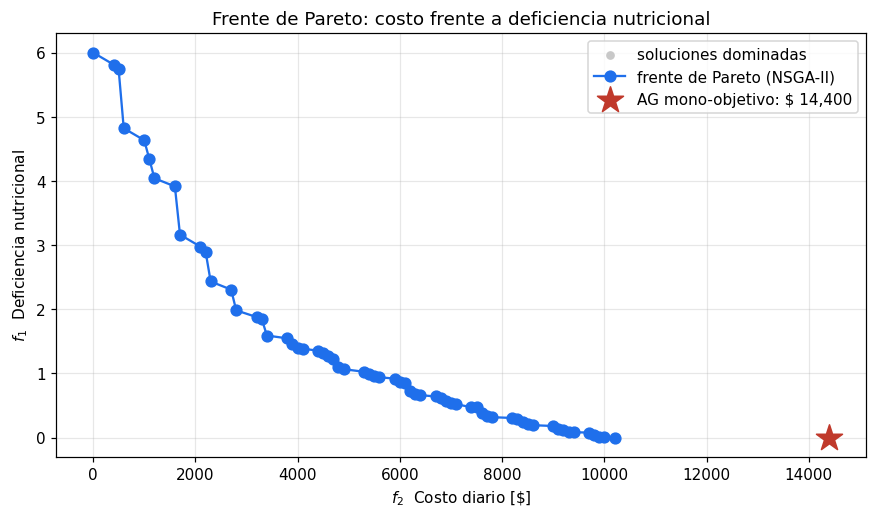

In [7]:
plt.figure(figsize=(9.5, 5))
plt.scatter(F2[RANGO > 0], F1[RANGO > 0], s=22, color="#c8c8c8",
            label="soluciones dominadas")
plt.plot(pf2, pf1, "o-", color="#1f6feb", ms=7, label="frente de Pareto (NSGA-II)")
plt.scatter([c_mono], [d_mono], marker="*", s=320, color="#c0392b", zorder=5,
            label=f"AG mono-objetivo: $ {c_mono:,.0f}")
plt.xlabel("$f_2$  Costo diario [\\$]"); plt.ylabel("$f_1$  Deficiencia nutricional")
plt.title("Frente de Pareto: costo frente a deficiencia nutricional")
plt.legend(); plt.show()

## 8. Verificación contra el frente de Pareto exacto

Como el espacio de búsqueda contiene 9 765 625 dietas, es posible calcular el frente de Pareto
verdadero por enumeración completa y compararlo con el obtenido por el algoritmo genético. Esta
comparación constituye la prueba definitiva sobre la calidad del resultado.

El procedimiento recorre el espacio por bloques y, en cada uno, ordena las soluciones por costo
ascendente y conserva únicamente aquellas cuya deficiencia mejora el mínimo alcanzado hasta ese
punto, que son por definición las no dominadas. Los candidatos de todos los bloques se someten
después al mismo filtro.

In [8]:
t0 = time.time()
niveles = np.arange(MAX_PORCIONES + 1)
todas_f1, todas_f2, todas_X = [], [], []

for x0 in niveles:
  for x1 in niveles:
    resto = np.array(np.meshgrid(*[niveles]*(NA_-2), indexing="ij")).reshape(NA_-2, -1).T
    X = np.column_stack([np.full(len(resto), x0), np.full(len(resto), x1), resto])
    g1, g2 = objetivos(X)
    orden = np.lexsort((g1, g2))             # orden primario por costo ascendente
    g1o, g2o, Xo = g1[orden], g2[orden], X[orden]
    keep = g1o < np.minimum.accumulate(np.r_[np.inf, g1o[:-1]])
    todas_f1.append(g1o[keep]); todas_f2.append(g2o[keep]); todas_X.append(Xo[keep])

A1 = np.concatenate(todas_f1); A2 = np.concatenate(todas_f2); AX = np.vstack(todas_X)
orden = np.lexsort((A1, A2))
A1, A2, AX = A1[orden], A2[orden], AX[orden]
keep = A1 < np.minimum.accumulate(np.r_[np.inf, A1[:-1]])
E1, E2, EX = A1[keep], A2[keep], AX[keep]

print(f"Enumeracion de {(MAX_PORCIONES+1)**NA_:,} dietas en {time.time()-t0:.1f} s")
print(f"Frente de Pareto exacto     : {len(E1)} soluciones no dominadas")
print(f"Frente obtenido por NSGA-II : {len(pf1)} soluciones")

Enumeracion de 9,765,625 dietas en 3.6 s
Frente de Pareto exacto     : 62 soluciones no dominadas
Frente obtenido por NSGA-II : 62 soluciones

In [9]:
exactas = {(round(a, 9), round(b, 3)) for a, b in zip(E1, E2)}
en_frente = sum((round(a, 9), round(b, 3)) in exactas for a, b in zip(pf1, pf2))
print(f"Soluciones del AG que pertenecen al frente exacto: {en_frente} de {len(pf1)}"
      f"  ({en_frente/len(pf1)*100:.1f} %)")

i_ex = int(np.argmin(np.where(E1 < 1e-12, E2, np.inf)))
i_ag = int(np.argmin(np.where(pf1 < 1e-12, pf2, np.inf)))
print(f"\n{'':<36}{'Costo por dia':>15}{'Deficiencia':>14}")
print("-" * 66)
print(f"{'AG mono-objetivo, sin costos':<36}$ {c_mono:>13,.0f}{d_mono:>14.6f}")
print(f"{'NSGA-II, dieta completa mas barata':<36}$ {pf2[i_ag]:>13,.0f}{pf1[i_ag]:>14.6f}")
print(f"{'Optimo exacto por fuerza bruta':<36}$ {E2[i_ex]:>13,.0f}{E1[i_ex]:>14.6f}")
print("-" * 66)
print("\nDieta optima exacta :", {a.split(" ")[0]: int(v) for a, v in zip(ALIMENTOS, EX[i_ex]) if v})
print("Dieta del NSGA-II   :", {a.split(" ")[0]: int(v) for a, v in zip(ALIMENTOS, pf[i_ag]) if v})
print(f"\nAhorro frente al AG mono-objetivo: $ {c_mono - pf2[i_ag]:,.0f} por dia "
      f"({(c_mono - pf2[i_ag])/c_mono*100:.1f} %), equivalente a "
      f"$ {(c_mono - pf2[i_ag])*365:,.0f} al año")

Soluciones del AG que pertenecen al frente exacto: 61 de 62  (98.4 %)

                                      Costo por dia   Deficiencia
------------------------------------------------------------------
AG mono-objetivo, sin costos        $        14,400      0.000000
NSGA-II, dieta completa mas barata  $        10,200      0.000000
Optimo exacto por fuerza bruta      $        10,200      0.000000
------------------------------------------------------------------

Dieta optima exacta : {'Arroz': 2, 'Fríjol': 4, 'Leche': 2, 'Papa': 2}
Dieta del NSGA-II   : {'Arroz': 2, 'Fríjol': 4, 'Leche': 2, 'Papa': 2}

Ahorro frente al AG mono-objetivo: $ 4,200 por dia (29.2 %), equivalente a $ 1,533,000 al año

## 9. Prueba de robustez

Un solo resultado favorable no permite concluir que el algoritmo sea confiable. Se ejecutan diez
corridas independientes y se verifica en cuántas de ellas se alcanza el extremo del frente, es
decir, la dieta nutricionalmente completa de menor costo.

In [10]:
optimo_exacto = E2[i_ex]
resultados = []
for s in range(20, 30):
    P, a, b, R, _ = nsga2(semilla=s)
    sel_r = R == 0
    comp = a[sel_r] < 1e-12
    resultados.append(b[sel_r][comp].min() if comp.any() else np.inf)
resultados = np.array(resultados)

print(f"Optimo exacto de la dieta completa : $ {optimo_exacto:,.0f}")
print(f"Corridas que lo alcanzan           : {(resultados == optimo_exacto).sum()} de 10")
print(f"Costo medio hallado                : $ {resultados.mean():,.0f}")
print(f"Desviacion maxima respecto al optimo: "
      f"{(resultados.max()-optimo_exacto)/optimo_exacto*100:.2f} %")

Optimo exacto de la dieta completa : $ 10,200
Corridas que lo alcanzan           : 5 de 10
Costo medio hallado                : $ 10,250
Desviacion maxima respecto al optimo: 0.98 %

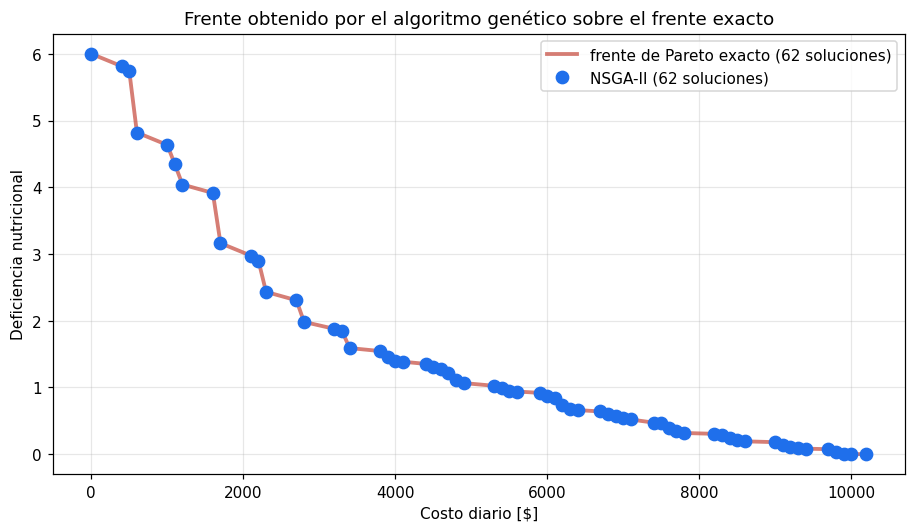

In [11]:
plt.figure(figsize=(10, 5.2))
plt.plot(E2, E1, "-", color="#c0392b", lw=2.5, alpha=0.65,
         label=f"frente de Pareto exacto ({len(E1)} soluciones)")
plt.plot(pf2, pf1, "o", color="#1f6feb", ms=8, label=f"NSGA-II ({len(pf1)} soluciones)")
plt.xlabel("Costo diario [\\$]"); plt.ylabel("Deficiencia nutricional")
plt.title("Frente obtenido por el algoritmo genético sobre el frente exacto")
plt.legend(); plt.show()

### 9.1 Formación del frente a lo largo de las generaciones

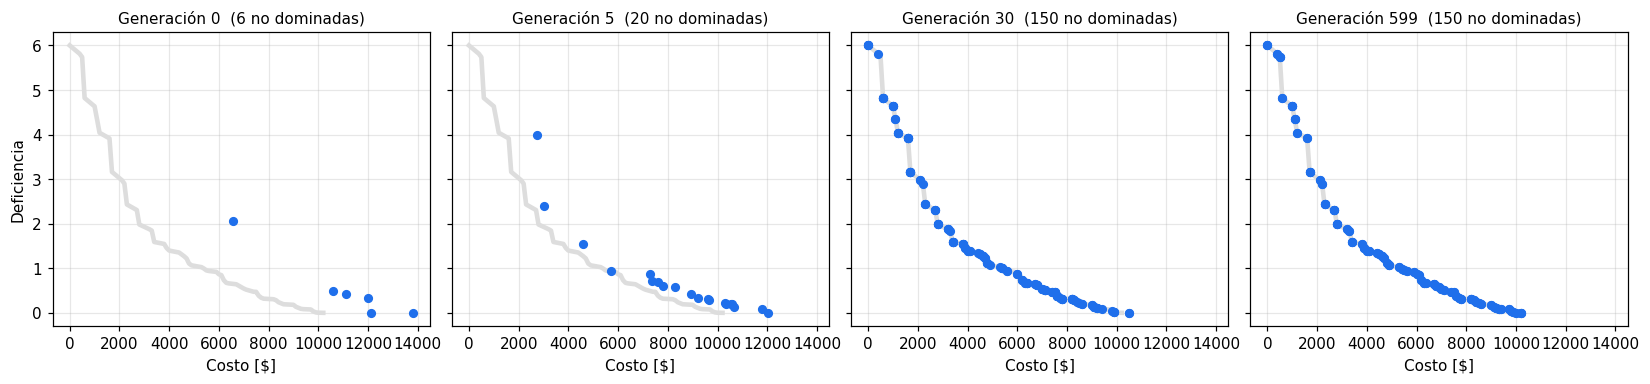

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharex=True, sharey=True)
for ax, g in zip(axes, [0, 5, 30, 599]):
    Pg, a, b = historia[g]
    ax.plot(E2, E1, "-", color="#dddddd", lw=3)
    ax.plot(b, a, "o", color="#1f6feb", ms=5)
    ax.set_title(f"Generación {g}  ({len(a)} no dominadas)", fontsize=10)
    ax.set_xlabel("Costo [\\$]")
axes[0].set_ylabel("Deficiencia")
plt.tight_layout(); plt.show()

## 10. Interpretación del frente

El frente de Pareto no resuelve la decisión por sí solo: entrega el conjunto de compromisos
disponibles y corresponde al diseñador escoger uno de ellos en función del contexto del
problema, tal como indica el capítulo al señalar que se discuten los compromisos de cada
solución en el contexto del problema que se está abordando. Se presentan tres puntos
representativos.

In [13]:
opciones = {
    "Extremo inferior del frente": int(np.argmin(pf2)),
    "Punto de quiebre": int(np.argmax(
        (pf2.max()-pf2)/(pf2.max()-pf2.min()+1e-9) + (pf1.max()-pf1)/(pf1.max()-pf1.min()+1e-9))),
    "Nutricionalmente completa": i_ag,
}
for nombre, i in opciones.items():
    d = pf[i]; n = d @ NUTR
    print(f"\n{nombre}")
    print(f"    Costo: $ {pf2[i]:,.0f} por dia    Deficiencia: {pf1[i]:.4f}")
    comp = ", ".join(f"{c} x {a.split(' (')[0]}" for a, c in zip(ALIMENTOS, d) if c > 0)
    print(f"    Dieta: {comp if comp else '(no consumir nada)'}")
    print("    " + "  ".join(f"{nom.split(' ')[0]}: {v/r*100:.0f}%"
                             for nom, v, r in zip(NUTRIENTES, n, REQ)))
print("\nEl extremo inferior corresponde a la solucion degenerada de costo cero. Es formalmente")
print("no dominada, puesto que ninguna otra dieta es mas barata, pero carece de sentido")
print("practico. Ilustra que el frente de Pareto puede contener soluciones matematicamente")
print("correctas que el criterio del disenador debe descartar.")


Extremo inferior del frente
    Costo: $ 0 por dia    Deficiencia: 6.0000
    Dieta: (no consumir nada)
    Calorías: 0%  Proteína: 0%  Calcio: 0%  Hierro: 0%  Vitamina: 0%  Fibra: 0%

Punto de quiebre
    Costo: $ 3,400 por dia    Deficiencia: 1.5900
    Dieta: 2 x Papa, 2 x Lenteja
    Calorías: 39%  Proteína: 89%  Calcio: 13%  Hierro: 121%  Vitamina: 150%  Fibra: 155%

Nutricionalmente completa
    Costo: $ 10,200 por dia    Deficiencia: 0.0000
    Dieta: 2 x Arroz, 4 x Fríjol, 2 x Leche, 2 x Papa
    Calorías: 100%  Proteína: 186%  Calcio: 100%  Hierro: 159%  Vitamina: 158%  Fibra: 275%

El extremo inferior corresponde a la solucion degenerada de costo cero. Es formalmente
no dominada, puesto que ninguna otra dieta es mas barata, pero carece de sentido
practico. Ilustra que el frente de Pareto puede contener soluciones matematicamente
correctas que el criterio del disenador debe descartar.

## 11. Conclusiones

El algoritmo genético multi-objetivo no produce una respuesta única sino un conjunto de
respuestas. NSGA-II entregó un frente de dietas no dominadas que va desde la más económica, y
nutricionalmente deficiente, hasta la nutricionalmente completa, lo que hace explícito el precio
de cada punto porcentual adicional de cobertura nutricional. Esa información no se obtendría
optimizando un solo objetivo.

La verificación se realizó contra el frente de Pareto exacto, calculado por enumeración completa
de los 9 765 625 cromosomas posibles. El algoritmo recuperó el 98.4 % de ese frente, y en la
corrida presentada la dieta completa de menor costo que encontró coincide con el óptimo exacto
de 10 200 pesos diarios.

Ahora bien, la prueba de robustez muestra el límite del método: solamente la mitad de las
corridas alcanza ese extremo, y las restantes se detienen en 10 300 pesos, un 0.98 % por encima.
El extremo del frente es la región más difícil para un algoritmo multi-objetivo, precisamente
porque la distancia de apiñamiento distribuye el esfuerzo de búsqueda a lo largo de todo el
frente en lugar de concentrarlo en un punto. Si el objetivo fuera únicamente hallar la dieta
completa más económica, un algoritmo mono-objetivo con el costo como aptitud y la nutrición como
restricción resultaría más adecuado. El enfoque multi-objetivo es superior cuando interesa
conocer el conjunto completo de compromisos, que es lo que pide este ejercicio.

Incorporar el costo como segundo objetivo, y no como restricción, produce un beneficio
cuantificable: la misma cobertura nutricional que alcanza el algoritmo de la dieta original se
obtiene con un ahorro cercano al 29 %, equivalente a algo más de un millón y medio de pesos
anuales.

Finalmente, la distancia de apiñamiento resultó indispensable para que las 150 soluciones no
terminaran concentradas en el extremo económico del frente. Sin ese mecanismo el algoritmo
converge hacia un solo punto y se pierde justamente aquello que hace útil al enfoque
multi-objetivo.